In [87]:
import pyarrow
import fastparquet
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [88]:
notes = pd.read_parquet('~/Documents/GitHub/494-user-trajectories/students/ryder/sampled_user_month_traj.parquet', engine='fastparquet')
notes.columns
notes.head()

,participantId,userMonth,sportsNotesWritten,diaries_&_daily_lifeNotesWritten,business_&_entrepreneursNotesWritten,science_&_technologyNotesWritten,news_&_social_concernNotesWritten,otherNotesWritten,calendarMonth,notesWritten,...,propPoliticalRatingsRepAligned,propRatingsOnPoliticalNotes,notesRequested,numRequestsResultingInCrh,numRequestsResultingInNote,propRequestResultedInNote,propRequestResultedInCrh,calendarDate,activeMonth,month_role
0,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,0,0,0,0,0,0,0,2025-12,0,...,NaN,NaN,1,0.0,0.0,0.0,0.0,2025-12-01,True,single_post_requestor
1,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,1,0,0,0,0,0,0,2026-01,0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,2026-01-01,False,not_active
2,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,2,0,0,0,0,0,0,2026-02,0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,2026-02-01,False,not_active
3,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,0,0,0,0,0,0,0,2025-11,0,...,NaN,NaN,1,0.0,0.0,0.0,0.0,2025-11-01,True,single_post_requestor
4,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,1,0,0,0,0,0,0,2025-12,0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,2025-12-01,False,not_active


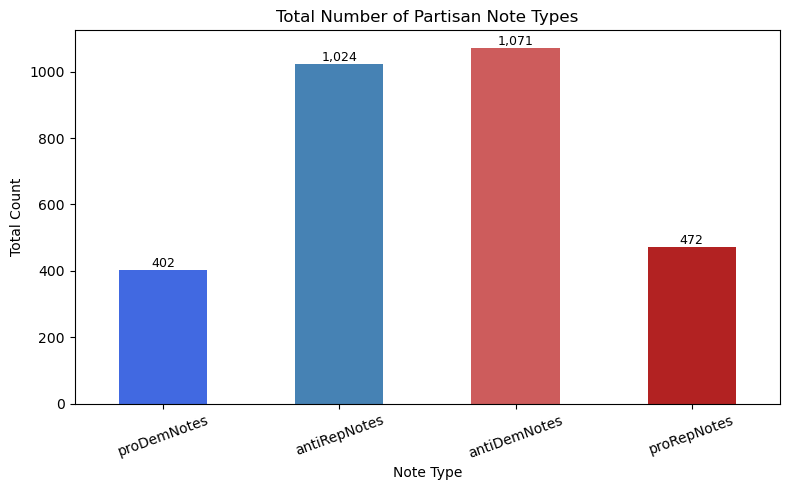

In [89]:
note_cols = ["proDemNotes", "antiRepNotes", "antiDemNotes", "proRepNotes"]
note_totals = users[note_cols].sum()

ax = note_totals.plot(kind="bar", figsize=(8, 5), color=["royalblue", "steelblue", "indianred", "firebrick"])
ax.set_xlabel("Note Type")
ax.set_ylabel("Total Count")
ax.set_title("Total Number of Partisan Note Types")
ax.tick_params(axis="x", rotation=20)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [90]:
notes_rated_by_participant = (
    notes.groupby('participantId', as_index=False)['notesRated']
    .sum()
    .rename(columns={'notesRated': 'totalNotesRated'})
)

notes_rated_by_participant['ratingDigits'] = (
    notes_rated_by_participant['totalNotesRated'].astype(int).astype(str).str.len()
)

users = notes.merge(
    notes_rated_by_participant[['participantId', 'ratingDigits']],
    on='participantId',
    how='left'
)

users.head(100)

,participantId,userMonth,sportsNotesWritten,diaries_&_daily_lifeNotesWritten,business_&_entrepreneursNotesWritten,science_&_technologyNotesWritten,news_&_social_concernNotesWritten,otherNotesWritten,calendarMonth,notesWritten,...,propRatingsOnPoliticalNotes,notesRequested,numRequestsResultingInCrh,numRequestsResultingInNote,propRequestResultedInNote,propRequestResultedInCrh,calendarDate,activeMonth,month_role,ratingDigits
0,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,0,0,0,0,0,0,0,2025-12,0,...,NaN,1,0.0,0.0,0.0,0.0,2025-12-01,True,single_post_requestor,1
1,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,1,0,0,0,0,0,0,2026-01,0,...,NaN,0,NaN,NaN,NaN,NaN,2026-01-01,False,not_active,1
2,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,2,0,0,0,0,0,0,2026-02,0,...,NaN,0,NaN,NaN,NaN,NaN,2026-02-01,False,not_active,1
3,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,0,0,0,0,0,0,0,2025-11,0,...,NaN,1,0.0,0.0,0.0,0.0,2025-11-01,True,single_post_requestor,1
4,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,1,0,0,0,0,0,0,2025-12,0,...,NaN,0,NaN,NaN,NaN,NaN,2025-12-01,False,not_active,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,5,0,0,0,0,0,0,2023-12,0,...,0.000000,0,NaN,NaN,NaN,NaN,2023-12-01,True,single_digit_rater,3
96,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,6,0,0,0,0,0,0,2024-01,0,...,0.500000,0,NaN,NaN,NaN,NaN,2024-01-01,True,double_digit_rater,3
97,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,7,0,0,0,0,0,0,2024-02,0,...,0.700000,0,NaN,NaN,NaN,NaN,2024-02-01,True,double_digit_rater,3
98,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,8,0,0,0,0,0,0,2024-03,0,...,0.000000,0,NaN,NaN,NaN,NaN,2024-03-01,True,single_note_rater,3


In [127]:
notes_written_by_participant = (
    notes.groupby('participantId', as_index=False)['notesWritten']
    .sum()
    .rename(columns={'notesWritten': 'totalNotesWritten'})
)

notes_written_by_participant['writingDigits'] = (
    notes_written_by_participant['totalNotesWritten'].astype(int).astype(str).str.len()
)

users = notes.merge(
    notes_written_by_participant[['participantId', 'writingDigits']],
    on='participantId',
    how='left'
)

users.head(100)

,participantId,userMonth,sportsNotesWritten,diaries_&_daily_lifeNotesWritten,business_&_entrepreneursNotesWritten,science_&_technologyNotesWritten,news_&_social_concernNotesWritten,otherNotesWritten,calendarMonth,notesWritten,...,month_role,lifetimeRatingAlignment,partisanRatings,demAlignedRatings_prop,repAlignedRatings_prop,proDemRatings_prop,antiRepRatings_prop,antiDemRatings_prop,proRepRatings_prop,writingDigits
0,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,0,0,0,0,0,0,0,2025-12,0,...,single_post_requestor,<NA>,0,NaN,NaN,NaN,NaN,NaN,NaN,1
1,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,1,0,0,0,0,0,0,2026-01,0,...,not_active,<NA>,0,NaN,NaN,NaN,NaN,NaN,NaN,1
2,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,2,0,0,0,0,0,0,2026-02,0,...,not_active,<NA>,0,NaN,NaN,NaN,NaN,NaN,NaN,1
3,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,0,0,0,0,0,0,0,2025-11,0,...,single_post_requestor,<NA>,0,NaN,NaN,NaN,NaN,NaN,NaN,1
4,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,1,0,0,0,0,0,0,2025-12,0,...,not_active,<NA>,0,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,5,0,0,0,0,0,0,2023-12,0,...,single_digit_rater,rep,0,NaN,NaN,NaN,NaN,NaN,NaN,1
96,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,6,0,0,0,0,0,0,2024-01,0,...,double_digit_rater,rep,12,0.250000,0.750000,0.0,0.250000,0.416667,0.333333,1
97,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,7,0,0,0,0,0,0,2024-02,0,...,double_digit_rater,rep,7,0.285714,0.714286,0.0,0.285714,0.428571,0.285714,1
98,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,8,0,0,0,0,0,0,2024-03,0,...,single_note_rater,rep,0,NaN,NaN,NaN,NaN,NaN,NaN,1


### proportional partisanship measures for ratings and notes

In [91]:
users['partisanRatings'] = users['demAlignedRatings'] + users['repAlignedRatings']

users['proDemRatings_prop'] = users['proDemRatings'] / users['partisanRatings'].replace(0, np.nan)
users['antiRepRatings_prop'] = users['antiRepRatings'] / users['partisanRatings'].replace(0, np.nan)
users['antiDemRatings_prop'] = users['antiDemRatings'] / users['partisanRatings'].replace(0, np.nan)
users['proRepRatings_prop'] = users['proRepRatings'] / users['partisanRatings'].replace(0, np.nan)

users['demAlignedRatings_prop'] = users['demAlignedRatings'] / users['partisanRatings'].replace(0, np.nan)
users['repAlignedRatings_prop'] = users['repAlignedRatings'] / users['partisanRatings'].replace(0, np.nan)

In [92]:
users['partisanNotes'] = users['demAlignedNotes'] + users['repAlignedNotes']

users['proDemNotes_prop'] = users['proDemNotes'] / users['partisanNotes'].replace(0, np.nan)
users['antiRepNotes_prop'] = users['antiRepNotes'] / users['partisanNotes'].replace(0, np.nan)
users['antiDemNotes_prop'] = users['antiDemNotes'] / users['partisanNotes'].replace(0, np.nan)
users['proRepNotes_prop'] = users['proRepNotes'] / users['partisanNotes'].replace(0, np.nan)

users['demAlignedNotes_prop'] = users['demAlignedNotes'] / users['partisanNotes'].replace(0, np.nan)
users['repAlignedNotes_prop'] = users['repAlignedNotes'] / users['partisanNotes'].replace(0, np.nan)

### Rating Alignments -- cutoffs for defining a rater as partisan.

In [93]:
alignment_lower = 0.25
alignment_upper = 1 - alignment_lower

users["ratingAlignment"] = pd.Series(
    np.select(
        [
            users["demAlignedRatings_prop"] >= alignment_upper,
            users["demAlignedRatings_prop"] <= alignment_lower,
            users["demAlignedRatings_prop"].between(alignment_lower, alignment_upper, inclusive="neither"),
        ],
        ["dem", "rep", "mixed"],
        default=None,
    ),
    index=users.index,
    dtype="string",
)

In [119]:
alignment_lower = 0.25
alignment_upper = 1 - alignment_lower

users["writingAlignment"] = pd.Series(
    np.select(
        [
            users["demAlignedNotes_prop"] >= alignment_upper,
            users["demAlignedNotes_prop"] <= alignment_lower,
            users["demAlignedNotes_prop"].between(alignment_lower, alignment_upper, inclusive="neither"),
        ],
        ["dem", "rep", "mixed"],
        default=None,
    ),
    index=users.index,
    dtype="string",
)

In [94]:
dem_rater_count = users.loc[users["ratingAlignment"] == "dem", "participantId"].nunique()
mixed_rater_count = users.loc[users["ratingAlignment"] == "mixed", "participantId"].nunique()
rep_rater_count = users.loc[users["ratingAlignment"] == "rep", "participantId"].nunique()

print(f"{dem_rater_count}, {mixed_rater_count}, {rep_rater_count}")

3796, 2725, 3533


In [120]:
dem_writer_count = users.loc[users["writingAlignment"] == "dem", "participantId"].nunique()
mixed_writer_count = users.loc[users["writingAlignment"] == "mixed", "participantId"].nunique()
rep_writer_count = users.loc[users["writingAlignment"] == "rep", "participantId"].nunique()

print(f"{dem_writer_count}, {mixed_writer_count}, {rep_writer_count}")

407, 114, 408


### earliest and latest months of activity

In [95]:
earliest_month = notes.groupby('participantId')['calendarMonth'].min().reset_index()
earliest_month.columns = ['participantId', 'earliestMonth']
users = users.merge(earliest_month, on='participantId', how='left')

In [96]:
last_month = (
    users.loc[users["activeMonth"] == True]
    .groupby("participantId")["calendarMonth"]
    .max()
    .reset_index()
    .rename(columns={"calendarMonth": "lastMonth"})
)
users = users.merge(last_month, on="participantId", how="left")

### proportions of kinds of aligned ratings, by propensity

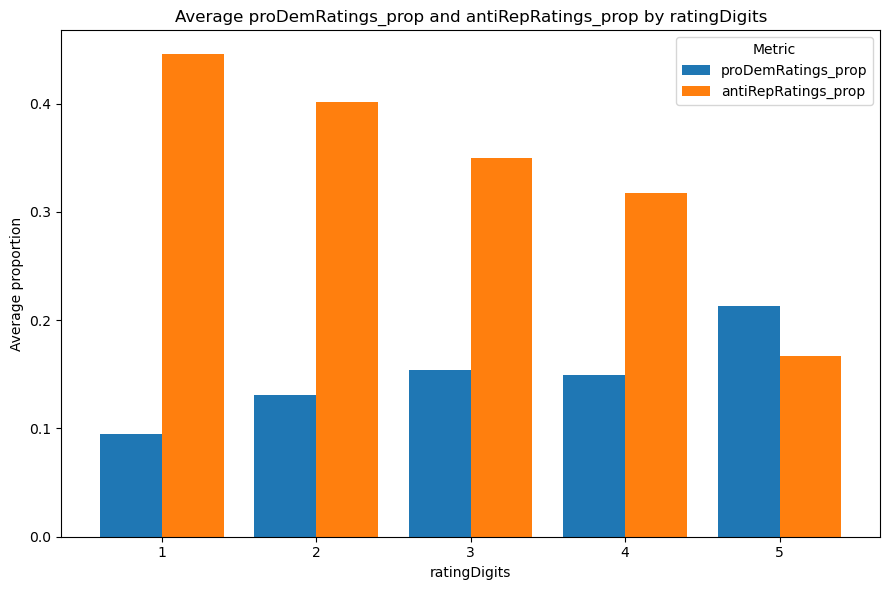

In [97]:
avg_props_by_digits_dem = (
    users.groupby("ratingDigits")[["proDemRatings_prop", "antiRepRatings_prop"]]
    .mean()
    .sort_index()
)

ax = avg_props_by_digits_dem.plot(kind="bar", figsize=(9, 6), width=0.8)
ax.set_xlabel("ratingDigits")
ax.set_ylabel("Average proportion")
ax.set_title('Average proDemRatings_prop and antiRepRatings_prop by ratingDigits')
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

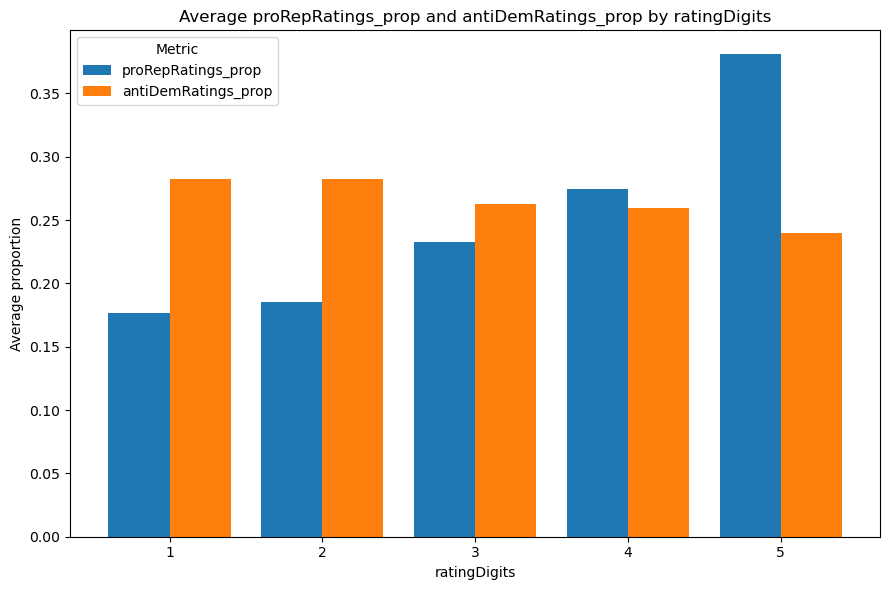

In [98]:
avg_props_by_digits_rep = (
    users.groupby("ratingDigits")[["proRepRatings_prop", "antiDemRatings_prop"]]
    .mean()
    .sort_index()
)

ax = avg_props_by_digits_rep.plot(kind="bar", figsize=(9, 6), width=0.8)
ax.set_xlabel("ratingDigits")
ax.set_ylabel("Average proportion")
ax.set_title("Average proRepRatings_prop and antiDemRatings_prop by ratingDigits")
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

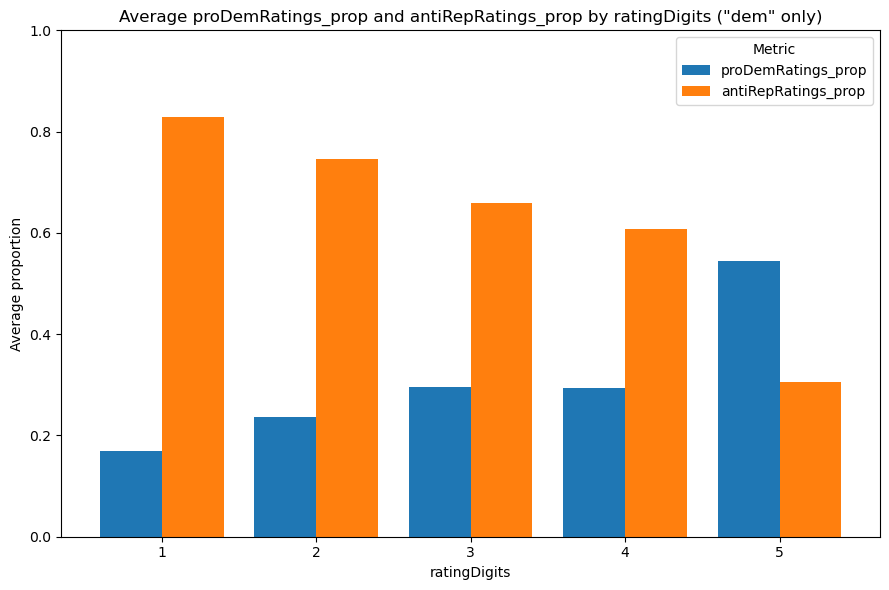

In [99]:
dem_users = users[users["ratingAlignment"] == "dem"]

avg_props_by_digits_dem = (
    dem_users.groupby("ratingDigits")[["proDemRatings_prop", "antiRepRatings_prop"]]
    .mean()
    .sort_index()
)

ax = avg_props_by_digits_dem.plot(kind="bar", figsize=(9, 6), width=0.8)
ax.set_xlabel("ratingDigits")
ax.set_ylabel("Average proportion")
ax.set_title('Average proDemRatings_prop and antiRepRatings_prop by ratingDigits ("dem" only)')
ax.legend(title="Metric")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

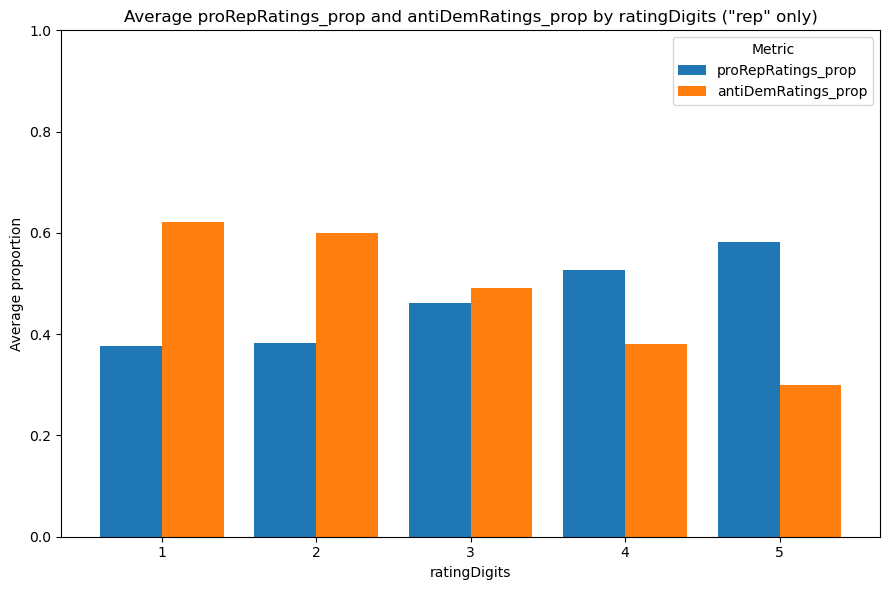

In [100]:
rep_users = users[users["ratingAlignment"] == "rep"]

avg_props_by_digits_dem = (
    rep_users.groupby("ratingDigits")[["proRepRatings_prop", "antiDemRatings_prop"]]
    .mean()
    .sort_index()
)

ax = avg_props_by_digits_dem.plot(kind="bar", figsize=(9, 6), width=0.8)
ax.set_xlabel("ratingDigits")
ax.set_ylabel("Average proportion")
ax.set_title('Average proRepRatings_prop and antiDemRatings_prop by ratingDigits ("rep" only)')
ax.legend(title="Metric")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

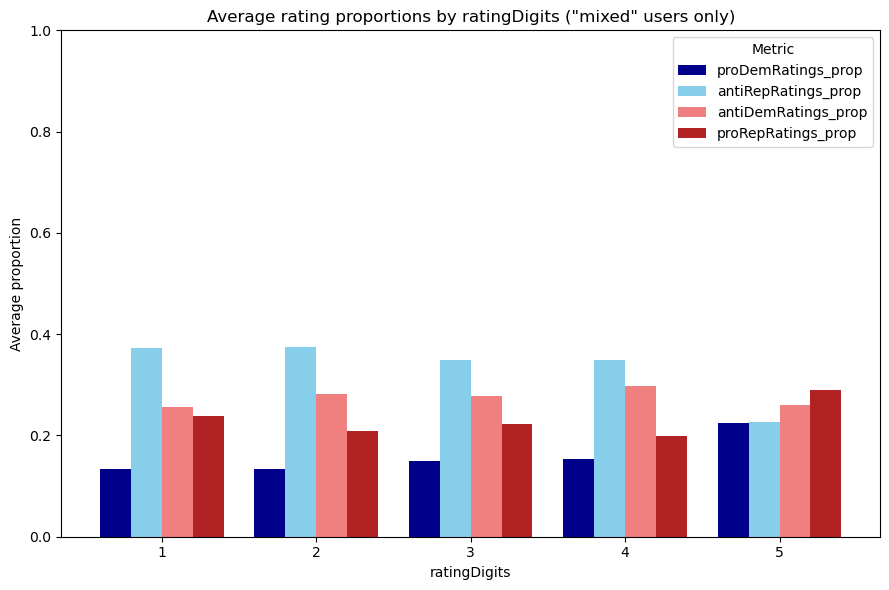

In [101]:
mixed_users = users[users["ratingAlignment"] == "mixed"]

avg_props_by_digits_mixed = (
    mixed_users.groupby("ratingDigits")[["proDemRatings_prop", "antiRepRatings_prop", "antiDemRatings_prop", "proRepRatings_prop"]]
    .mean()
    .sort_index()
)

ax = avg_props_by_digits_mixed.plot(
    kind="bar",
    figsize=(9, 6),
    width=0.8,
    color=["darkblue", "skyblue", "lightcoral", "firebrick"],
)

ax.set_xlabel("ratingDigits")
ax.set_ylabel("Average proportion")
ax.set_title('Average rating proportions by ratingDigits ("mixed" users only)')
ax.legend(title="Metric")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### proportions of kinds of aligned note-authorship, by propensity

In [ ]:
avg_props_by_digits_dem = (
    users.groupby("ratingDigits")[["proDemRatings_prop", "antiRepRatings_prop"]]
    .mean()
    .sort_index()
)

ax = avg_props_by_digits_dem.plot(kind="bar", figsize=(9, 6), width=0.8)
ax.set_xlabel("ratingDigits")
ax.set_ylabel("Average proportion")
ax.set_title('Average proDemRatings_prop and antiRepRatings_prop by ratingDigits')
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Lifetime analyses

In [103]:
lifetime_alignment = (
    users.loc[users["ratingAlignment"].notna(), ["participantId", "ratingAlignment"]]
    .groupby("participantId")["ratingAlignment"]
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else pd.NA)
)

notes["lifetimeRatingAlignment"] = notes["participantId"].map(lifetime_alignment).astype("string")

notes[["participantId", "lifetimeRatingAlignment"]].head(100)

,participantId,lifetimeRatingAlignment
0,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,<NA>
1,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,<NA>
2,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,<NA>
3,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,<NA>
4,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,<NA>
...,...,...
95,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,rep
96,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,rep
97,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,rep
98,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,rep


In [104]:
notes["partisanRatings"] = notes["demAlignedRatings"] + notes["repAlignedRatings"]
notes["demAlignedRatings_prop"] = notes["demAlignedRatings"] / notes["partisanRatings"].replace(0, np.nan)
notes["repAlignedRatings_prop"] = notes["repAlignedRatings"] / notes["partisanRatings"].replace(0, np.nan)

notes["proDemRatings_prop"] = notes["proDemRatings"] / notes["partisanRatings"].replace(0, np.nan)
notes["antiRepRatings_prop"] = notes["antiRepRatings"] / notes["partisanRatings"].replace(0, np.nan)
notes["antiDemRatings_prop"] = notes["antiDemRatings"] / notes["partisanRatings"].replace(0, np.nan)
notes["proRepRatings_prop"] = notes["proRepRatings"] / notes["partisanRatings"].replace(0, np.nan)

In [105]:
# Prepare data for plotting
facet_col = "lifetimeRatingAlignment"
value_cols = ["proDemRatings_prop", "antiRepRatings_prop", "antiDemRatings_prop", "proRepRatings_prop"]

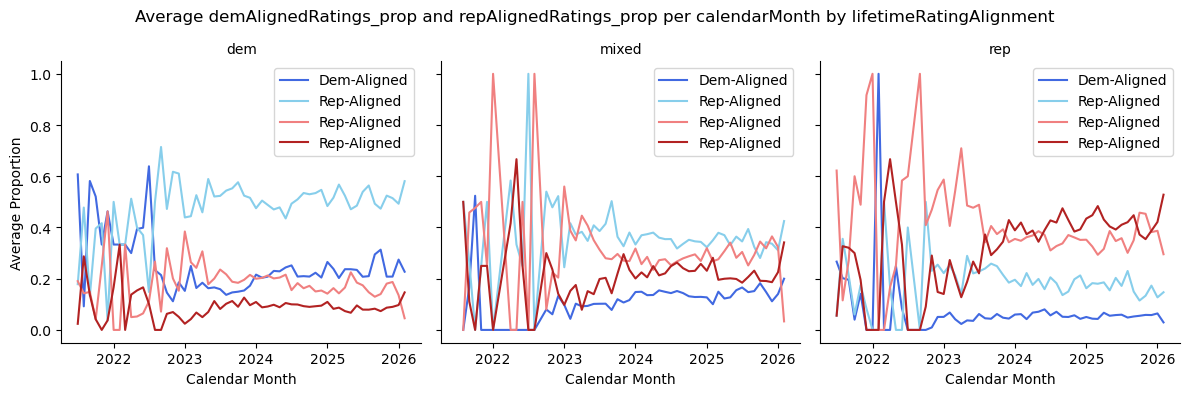

In [106]:
# Filter out missing values for alignment and calendarMonth
plot_data = notes.dropna(subset=[facet_col, "calendarMonth"] + value_cols).copy()
plot_data["calendarMonth"] = pd.to_datetime(plot_data["calendarMonth"], errors="coerce")
plot_data = plot_data.dropna(subset=["calendarMonth"])

# Compute averages per group
avg_per_month = (
    plot_data
    .groupby([facet_col, "calendarMonth"])[value_cols]
    .mean()
    .reset_index()
)

# Plot using seaborn's FacetGrid
g = sns.FacetGrid(
    avg_per_month,
    col=facet_col,
    col_wrap=3,
    height=4,
    sharey=True,
    sharex=True
)

g.map_dataframe(
    sns.lineplot,
    x="calendarMonth",
    y="proDemRatings_prop",
    label="Dem-Aligned",
    color="royalblue"
)
g.map_dataframe(
    sns.lineplot,
    x="calendarMonth",
    y="antiRepRatings_prop",
    label="Rep-Aligned",
    color="skyblue"
)
g.map_dataframe(
    sns.lineplot,
    x="calendarMonth",
    y="antiDemRatings_prop",
    label="Rep-Aligned",
    color="lightcoral"
)
g.map_dataframe(
    sns.lineplot,
    x="calendarMonth",
    y="proRepRatings_prop",
    label="Rep-Aligned",
    color="firebrick"
)

# Add legend and labels
for ax in g.axes.flatten():
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        handles = [
            plt.Line2D([0], [0], color="royalblue", label="Dem-Aligned"),
            plt.Line2D([0], [0], color="firebrick", label="Rep-Aligned"),
        ]
        labels = ["Dem-Aligned", "Rep-Aligned"]
    ax.legend(handles, labels)
    ax.set_ylabel("Average Proportion")
    ax.set_xlabel("Calendar Month")

g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Average demAlignedRatings_prop and repAlignedRatings_prop per calendarMonth by lifetimeRatingAlignment")
plt.show()

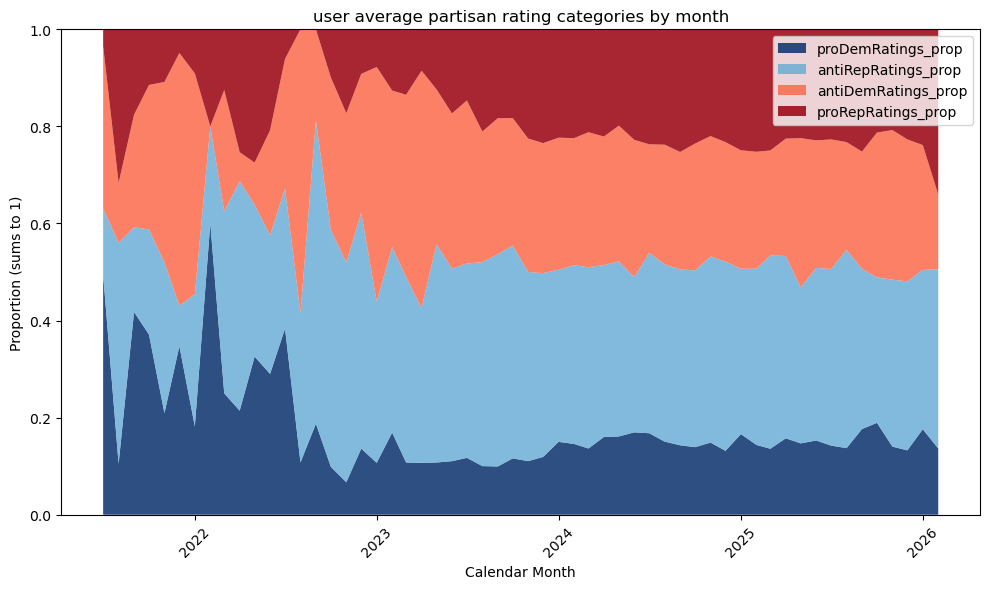

In [107]:
monthly_alignment = (
    plot_data.dropna(subset=["calendarMonth", "proDemRatings_prop", "antiRepRatings_prop", "antiDemRatings_prop", "proRepRatings_prop"])
    .assign(calendarMonth=lambda d: pd.to_datetime(d["calendarMonth"], errors="coerce"))
    .dropna(subset=["calendarMonth"])
    .groupby("calendarMonth")[["proDemRatings_prop", "antiRepRatings_prop", "antiDemRatings_prop", "proRepRatings_prop"]]
    .mean()
    .sort_index()
)

# Normalize each month to sum to 1 (stacked normalized)
monthly_alignment = monthly_alignment.div(monthly_alignment.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(
    monthly_alignment.index,
    monthly_alignment["proDemRatings_prop"],
    monthly_alignment["antiRepRatings_prop"],
    monthly_alignment["antiDemRatings_prop"],
    monthly_alignment["proRepRatings_prop"],
    labels=["proDemRatings_prop", "antiRepRatings_prop", "antiDemRatings_prop", "proRepRatings_prop"],
    colors=["#08306b", "#6baed6", "#fb6a4a", "#99000d"],
    alpha=0.85,
)

ax.set_title("user average partisan rating categories by month")
ax.set_xlabel("Calendar Month")
ax.set_ylabel("Proportion (sums to 1)")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

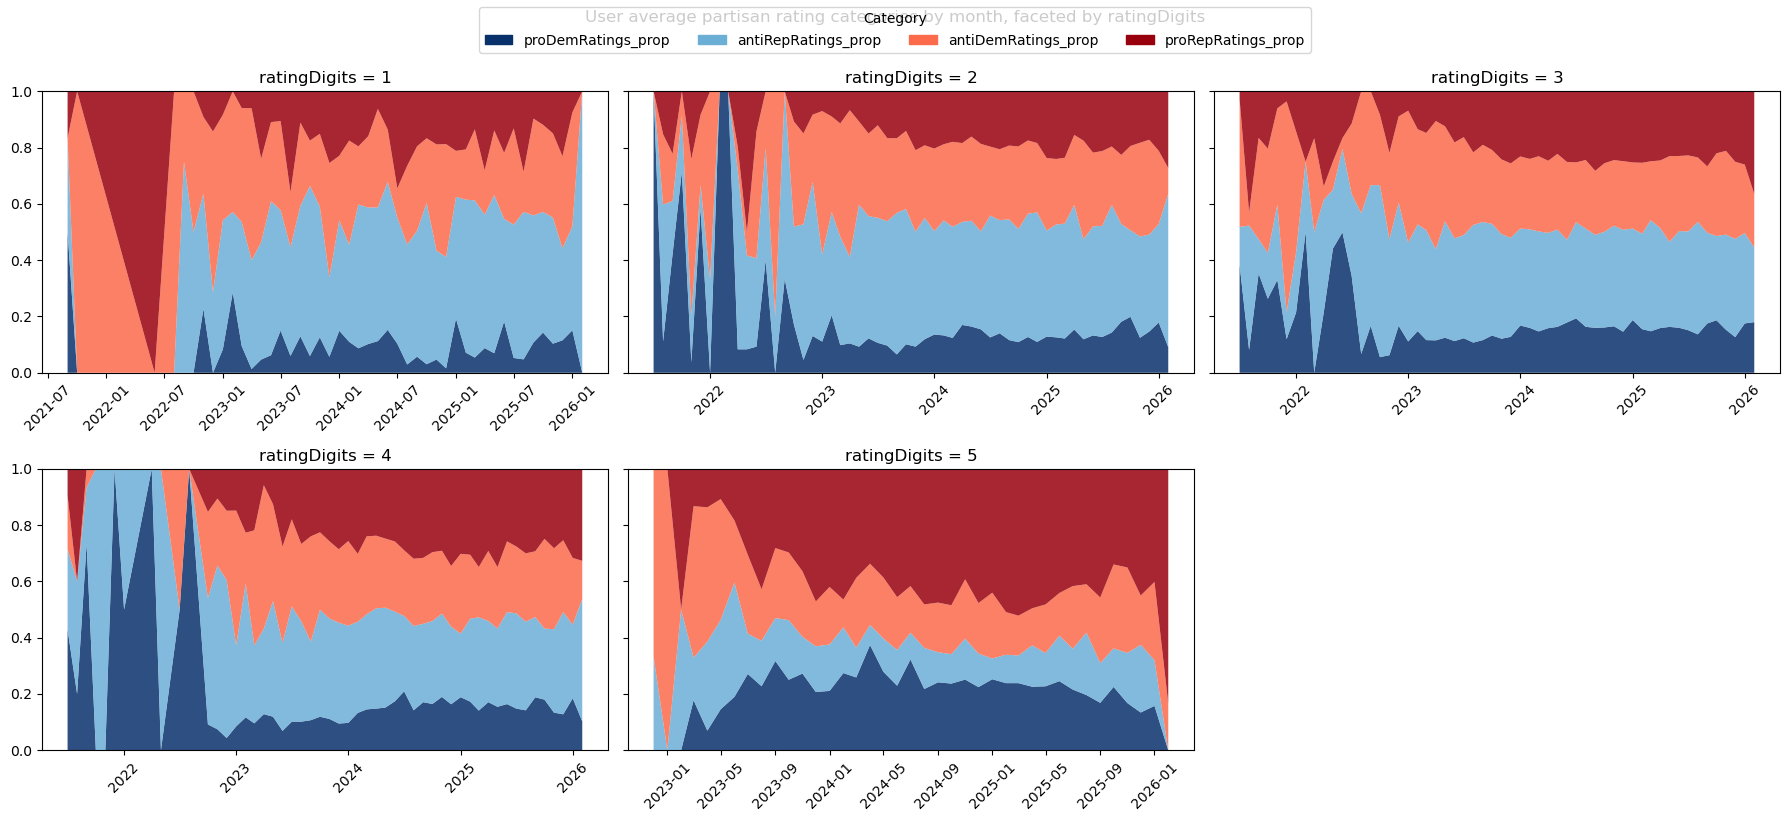

In [108]:
# Facet by ratingDigits, then compute monthly averages within each facet
src = (
    users.dropna(subset=["ratingDigits", "calendarMonth"] + value_cols)
    .copy()
)
src["calendarMonth"] = pd.to_datetime(src["calendarMonth"], errors="coerce")
src = src.dropna(subset=["calendarMonth"])

monthly_alignment = (
    src.groupby(["ratingDigits", "calendarMonth"])[value_cols]
    .mean()
    .sort_index()
)

# Normalize each (ratingDigits, month) row to sum to 1
monthly_alignment = monthly_alignment.div(monthly_alignment.sum(axis=1), axis=0)

digit_values = sorted(monthly_alignment.index.get_level_values("ratingDigits").unique())
n = len(digit_values)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows), sharex=False, sharey=True)
axes = np.array(axes).reshape(-1)

colors = ["#08306b", "#6baed6", "#fb6a4a", "#99000d"]

for i, d in enumerate(digit_values):
    ax = axes[i]
    sub = monthly_alignment.xs(d, level="ratingDigits")
    ax.stackplot(
        sub.index,
        sub["proDemRatings_prop"],
        sub["antiRepRatings_prop"],
        sub["antiDemRatings_prop"],
        sub["proRepRatings_prop"],
        labels=value_cols,
        colors=colors,
        alpha=0.85,
    )
    ax.set_title(f"ratingDigits = {d}")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
fig.legend(handles, value_cols, title="Category", loc="upper center", ncol=4)
fig.suptitle("User average partisan rating categories by month, faceted by ratingDigits", y=1.02)
fig.tight_layout()
plt.show()

### Analyses by earliest month

In [ ]:
monthly_alignment = (
    users.dropna(subset=["earliestMonth"] + value_cols)
    .assign(earliestMonth=lambda d: pd.to_datetime(d["earliestMonth"], errors="coerce"))
    .dropna(subset=["earliestMonth"])
    .groupby("earliestMonth")[value_cols]
    .mean()
    .sort_index()
)

# Normalize each month to sum to 1 (stacked normalized)
monthly_alignment = monthly_alignment.div(monthly_alignment.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(
    monthly_alignment.index,
    monthly_alignment["proDemRatings_prop"],
    monthly_alignment["antiRepRatings_prop"],
    monthly_alignment["antiDemRatings_prop"],
    monthly_alignment["proRepRatings_prop"],
    labels=value_cols,
    colors=["#08306b", "#6baed6", "#fb6a4a", "#99000d"],
    alpha=0.85,
)

ax.set_title("User average partisan rating categories by earliest month")
ax.set_xlabel("Earliest Month")
ax.set_ylabel("Proportion (sums to 1)")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

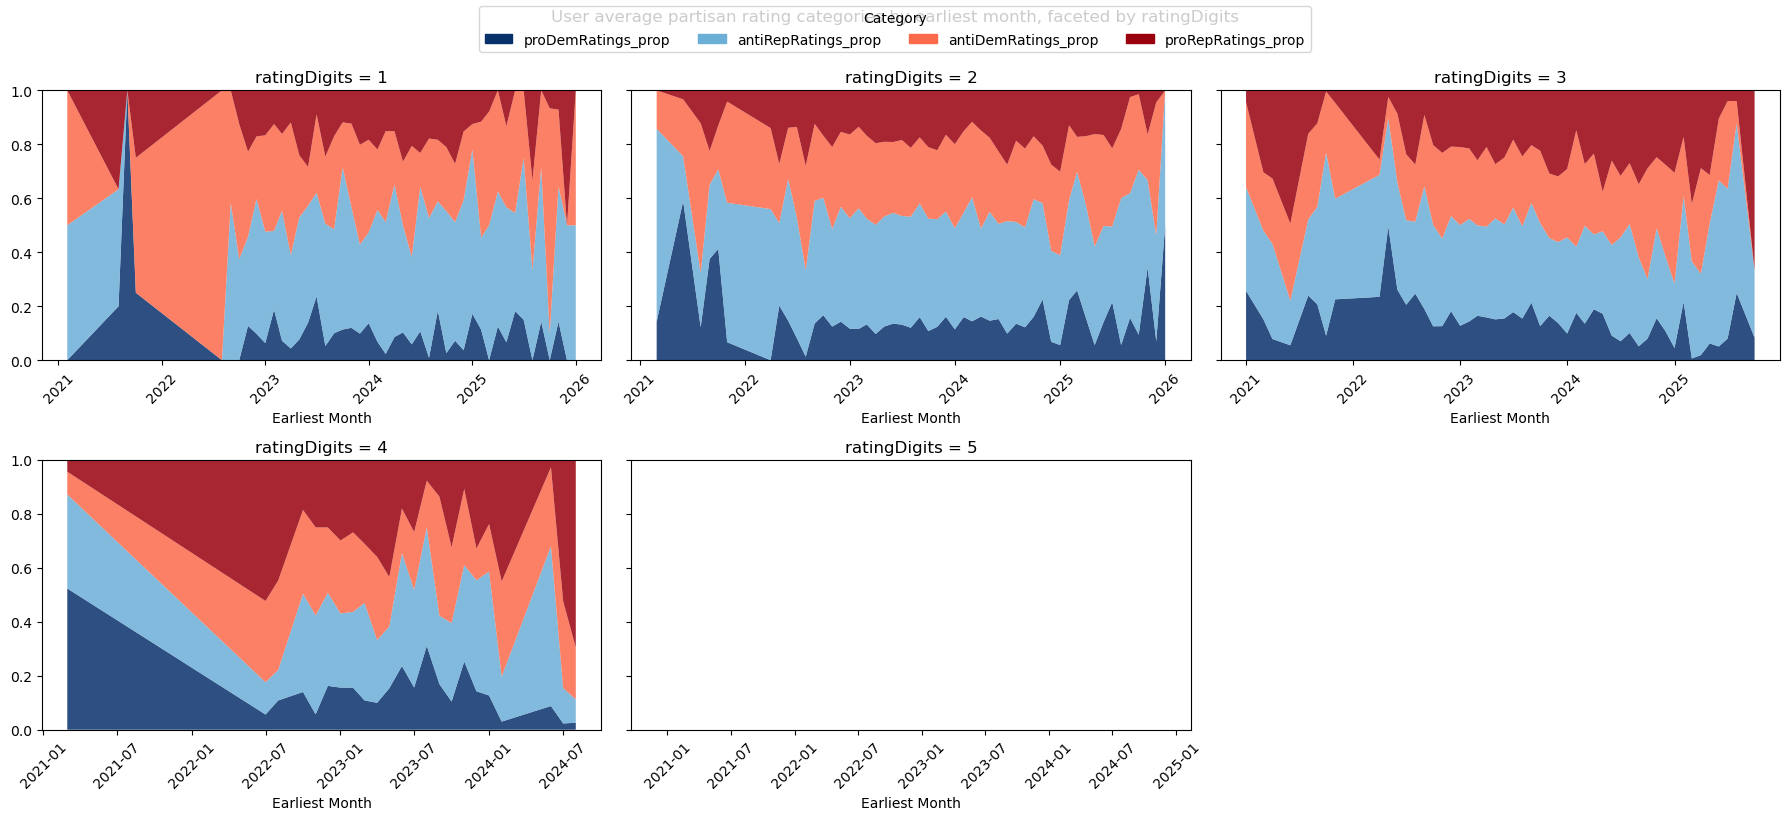

In [110]:
# Facet by ratingDigits, then compute averages by earliestMonth within each facet
src = (
    users.dropna(subset=["ratingDigits", "earliestMonth"] + value_cols)
    .copy()
)
src["earliestMonth"] = pd.to_datetime(src["earliestMonth"], errors="coerce")
src = src.dropna(subset=["earliestMonth"])

monthly_alignment = (
    src.groupby(["ratingDigits", "earliestMonth"])[value_cols]
    .mean()
    .sort_index()
)

# Normalize each (ratingDigits, earliestMonth) row to sum to 1
monthly_alignment = monthly_alignment.div(monthly_alignment.sum(axis=1), axis=0)

digit_values = sorted(monthly_alignment.index.get_level_values("ratingDigits").unique())
n = len(digit_values)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows), sharex=False, sharey=True)
axes = np.array(axes).reshape(-1)

colors = ["#08306b", "#6baed6", "#fb6a4a", "#99000d"]

for i, d in enumerate(digit_values):
    ax = axes[i]
    sub = monthly_alignment.xs(d, level="ratingDigits")
    ax.stackplot(
        sub.index,
        sub["proDemRatings_prop"],
        sub["antiRepRatings_prop"],
        sub["antiDemRatings_prop"],
        sub["proRepRatings_prop"],
        labels=value_cols,
        colors=colors,
        alpha=0.85,
    )
    ax.set_title(f"ratingDigits = {d}")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Earliest Month")
    ax.tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
fig.legend(handles, value_cols, title="Category", loc="upper center", ncol=4)
fig.suptitle("User average partisan rating categories by earliest month, faceted by ratingDigits", y=1.02)
fig.tight_layout()
plt.show()

In [136]:
value_cols = ["proDemNotes_prop", "antiRepNotes_prop", "antiDemNotes_prop", "proRepNotes_prop"]

In [137]:
monthly_alignment = (
    users.dropna(subset=["earliestMonth"] + value_cols)
    .assign(earliestMonth=lambda d: pd.to_datetime(d["earliestMonth"], errors="coerce"))
    .dropna(subset=["earliestMonth"])
    .groupby("earliestMonth")[value_cols]
    .mean()
    .sort_index()
)

# Normalize each month to sum to 1 (stacked normalized)
monthly_alignment = monthly_alignment.div(monthly_alignment.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(
    monthly_alignment.index,
    *[monthly_alignment[col] for col in value_cols],
    labels=value_cols,
    colors=["#08306b", "#6baed6", "#fb6a4a", "#99000d"],
    alpha=0.85,
)

ax.set_title("User average partisan note categories by earliest month")
ax.set_xlabel("Earliest Month")
ax.set_ylabel("Proportion (sums to 1)")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: ['earliestMonth', 'proDemNotes_prop', 'antiRepNotes_prop', 'antiDemNotes_prop', 'proRepNotes_prop']

In [128]:
monthly_alignment = (
    users.dropna(subset=["earliestMonth"] + value_cols)
    .assign(earliestMonth=lambda d: pd.to_datetime(d["earliestMonth"], errors="coerce"))
    .dropna(subset=["earliestMonth"])
    .groupby("earliestMonth")[value_cols]
    .mean()
    .sort_index()
)

# Normalize each month to sum to 1 (stacked normalized)
monthly_alignment = monthly_alignment.div(monthly_alignment.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(
    monthly_alignment.index,
    monthly_alignment["proDemNotes_prop"],
    monthly_alignment["antiRepNotes_prop"],
    monthly_alignment["antiDemNotes_prop"],
    monthly_alignment["proRepNotes_prop"],
    labels=value_cols,
    colors=["#08306b", "#6baed6", "#fb6a4a", "#99000d"],
    alpha=0.85,
)

ax.set_title("User average partisan rating categories by earliest month")
ax.set_xlabel("Earliest Month")
ax.set_ylabel("Proportion (sums to 1)")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: ['earliestMonth', 'proDemNotes_prop', 'antiRepNotes_prop', 'antiDemNotes_prop', 'proRepNotes_prop']

### Analyses by userMonth


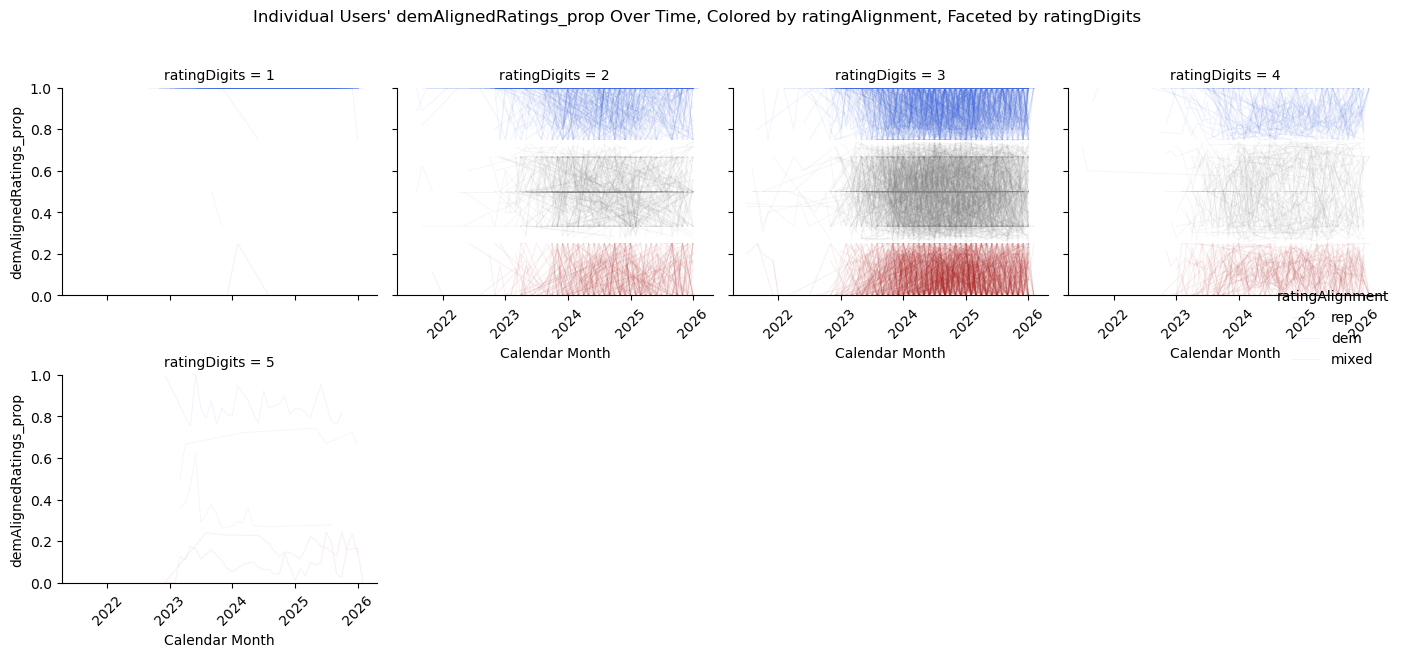

In [111]:
# Add ratingAlignment to plot_data
plot_data = users[["participantId", "calendarMonth", "ratingDigits", "demAlignedRatings_prop", "ratingAlignment"]].copy()
plot_data["calendarMonth"] = pd.to_datetime(plot_data["calendarMonth"], errors="coerce")
plot_data = plot_data.dropna(subset=["calendarMonth", "ratingDigits", "demAlignedRatings_prop", "ratingAlignment"]).sort_values(
    ["ratingDigits", "participantId", "calendarMonth"]
)

digit_order = sorted(plot_data["ratingDigits"].unique())
alignment_palette = {"dem": "royalblue", "rep": "firebrick", "mixed": "gray"}

g = sns.FacetGrid(
    plot_data,
    col="ratingDigits",
    col_order=digit_order,
    col_wrap=4,
    height=3.2,
    sharex=True,
    sharey=True,
    hue="ratingAlignment",
    palette=alignment_palette,
)

g.map_dataframe(
    sns.lineplot,
    x="calendarMonth",
    y="demAlignedRatings_prop",
    units="participantId",
    estimator=None,
    alpha=0.07,
    linewidth=0.7,
)

for ax in g.axes.flat:
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

g.set_axis_labels("Calendar Month", "demAlignedRatings_prop")
g.set_titles("ratingDigits = {col_name}")
g.add_legend(title="ratingAlignment")
g.fig.suptitle("Individual Users' demAlignedRatings_prop Over Time, Colored by ratingAlignment, Faceted by ratingDigits", y=1.02)
g.fig.tight_layout()
plt.show()

### User attrition

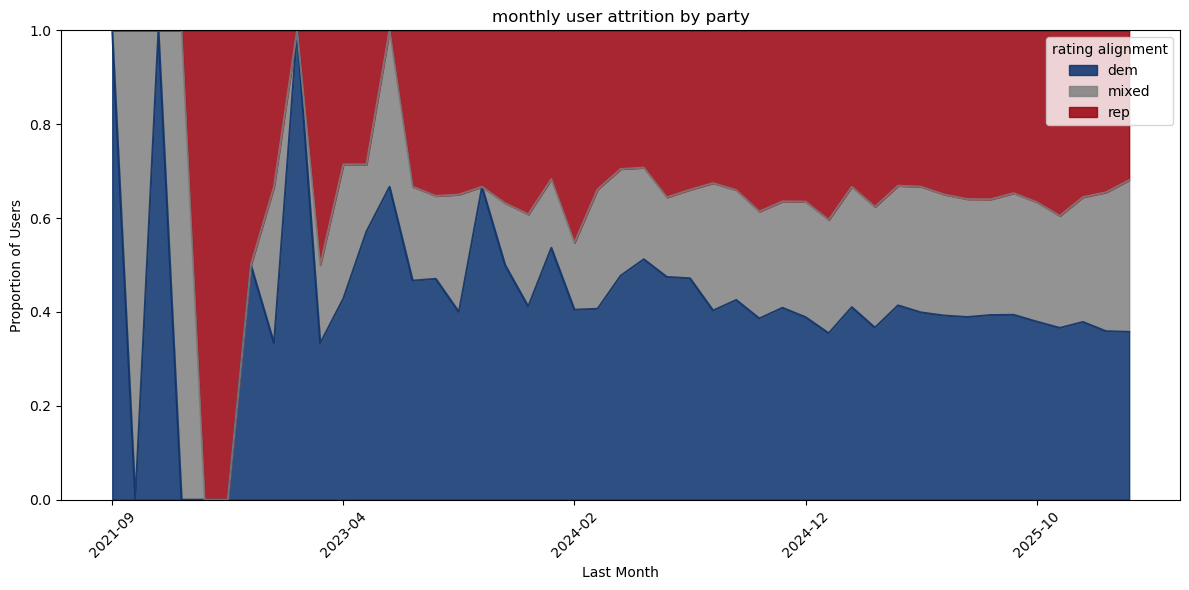

In [115]:
# Calculate the proportion of users by ratingAlignment within each latestMonth
user_counts = users.groupby(['lastMonth', 'ratingAlignment'])['participantId'].nunique().unstack(fill_value=0)
user_props = user_counts.div(user_counts.sum(axis=1), axis=0)

# Plot stacked line chart
fig, ax = plt.subplots(figsize=(12, 6))
user_props.plot.area(ax=ax, stacked=True, alpha=0.85, color=["#08306b", "gray", "#99000d"])
ax.set_title("monthly user attrition by party")
ax.set_xlabel("Last Month")
ax.set_ylabel("Proportion of Users")
ax.set_ylim(0, 1)
ax.legend(title="rating alignment", loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

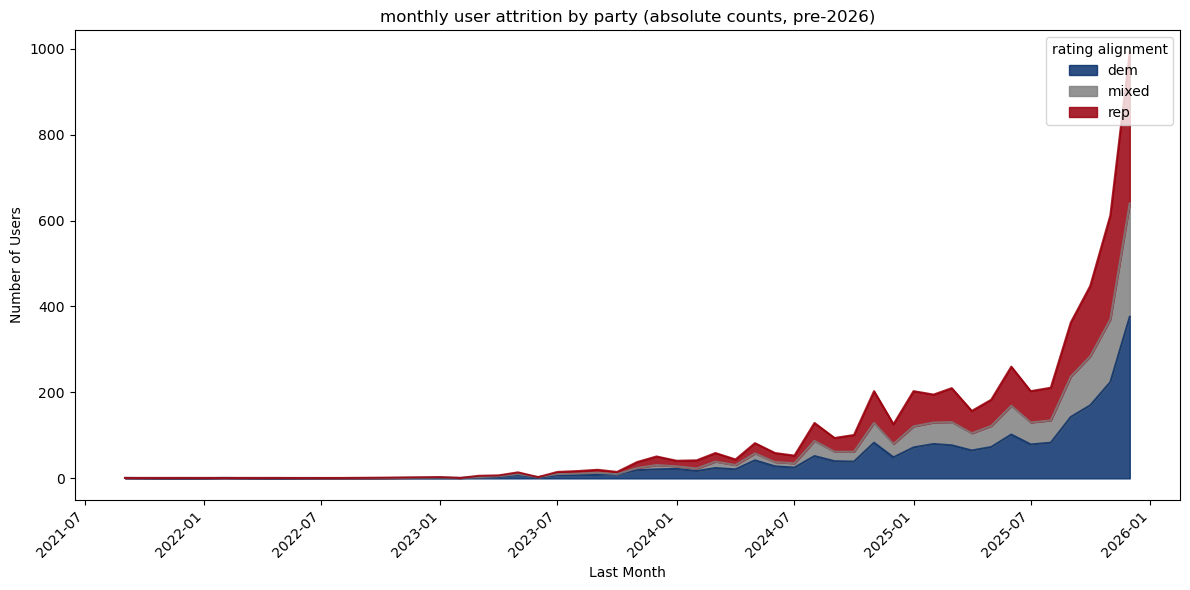

In [118]:
# Calculate the proportion of users by ratingAlignment within each latestMonth
user_counts = users.groupby(['lastMonth', 'ratingAlignment'])['participantId'].nunique().unstack(fill_value=0)
user_props = user_counts.div(user_counts.sum(axis=1), axis=0)

# Plot stacked line chart
fig, ax = plt.subplots(figsize=(12, 6))
user_props.plot.area(ax=ax, stacked=True, alpha=0.85, color=["#08306b", "gray", "#99000d"])
ax.set_title("monthly user attrition by party")
ax.set_xlabel("Last Month")
ax.set_ylabel("Proportion of Users")
ax.set_ylim(0, 1)
ax.legend(title="rating alignment", loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
# Replace the proportion plot with absolute user counts
ax.clear()

abs_counts = user_counts.reindex(columns=["dem", "mixed", "rep"], fill_value=0).copy()
abs_counts.index = pd.to_datetime(abs_counts.index, errors="coerce")
abs_counts = abs_counts.sort_index()

# Cut off to months before 2026
abs_counts = abs_counts[abs_counts.index < pd.Timestamp("2026-01-01")]

abs_counts.plot.area(ax=ax, stacked=True, alpha=0.85, color=["#08306b", "gray", "#99000d"])
ax.set_title("monthly user attrition by party (absolute counts, pre-2026)")
ax.set_xlabel("Last Month")
ax.set_ylabel("Number of Users")
ax.legend(title="rating alignment", loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Facet user attrition chart by ratingDigits
src = users.dropna(subset=["ratingDigits", "lastMonth", "ratingAlignment"]).copy()
src["lastMonth"] = pd.to_datetime(src["lastMonth"], errors="coerce")
src = src.dropna(subset=["lastMonth"])

digit_values = sorted(src["ratingDigits"].unique())
n = len(digit_values)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows), sharex=False, sharey=True)
axes = np.array(axes).reshape(-1)

col_order = ["dem", "mixed", "rep"]
colors = ["#08306b", "gray", "#99000d"]

for i, d in enumerate(digit_values):
    ax = axes[i]
    sub = src[src["ratingDigits"] == d]

    counts = (
        sub.groupby(["lastMonth", "ratingAlignment"])["participantId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=col_order, fill_value=0)
        .sort_index()
    )
    props = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    props.plot.area(ax=ax, stacked=True, alpha=0.85, color=colors, legend=False)
    ax.set_title(f"ratingDigits = {d}")
    ax.set_xlabel("Last Month")
    ax.set_ylabel("Proportion of Users")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
fig.legend(handles, col_order, title="rating alignment", loc="upper center", ncol=3)
fig.suptitle("Monthly user attrition by party, faceted by ratingDigits", y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
# Facet user attrition chart by ratingDigits
src = users.dropna(subset=["ratingDigits", "lastMonth", "ratingAlignment"]).copy()
src["lastMonth"] = pd.to_datetime(src["lastMonth"], errors="coerce")
src = src.dropna(subset=["lastMonth"])

digit_values = sorted(src["ratingDigits"].unique())
n = len(digit_values)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows), sharex=False, sharey=True)
axes = np.array(axes).reshape(-1)

col_order = ["dem", "mixed", "rep"]
colors = ["#08306b", "gray", "#99000d"]

for i, d in enumerate(digit_values):
    ax = axes[i]
    sub = src[src["ratingDigits"] == d]

    counts = (
        sub.groupby(["lastMonth", "ratingAlignment"])["participantId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=col_order, fill_value=0)
        .sort_index()
    )
    props = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    props.plot.area(ax=ax, stacked=True, alpha=0.85, color=colors, legend=False)
    ax.set_title(f"ratingDigits = {d}")
    ax.set_xlabel("Last Month")
    ax.set_ylabel("Proportion of Users")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
fig.legend(handles, col_order, title="rating alignment", loc="upper center", ncol=3)
fig.suptitle("Monthly user attrition by party, faceted by ratingDigits", y=1.02)
fig.tight_layout()
plt.show()